### NAME: Ankita Santosh Jagtap
### ROLL NO.: 2317048
### BATCH: C

## Machine Learning MINI PROJECT
# TITLE: FORECASTING STARTUP SUCCESS
### PROBLEM STATEMENT:
#### To develop a machine learning model that predicts the success level of startups based on key business atributes.This model can help investors and analysts assess the potential success of startups and make better data-driven decisions.

In [90]:
import pandas as pd

In [91]:
import numpy as np

In [92]:
import seaborn as sns

In [93]:
import matplotlib.pyplot as plt

In [94]:
df=pd.read_csv("startup_growth_investment_data.csv")

In [95]:
df

,Startup Name,Industry,Funding Rounds,Investment Amount (USD),Valuation (USD),Number of Investors,Country,Year Founded,Growth Rate (%)
0,Startup_1,Blockchain,8,1.335166e+09,6.621448e+09,50.0,Germany,2012,77.10
1,Startup_2,SaaS,2,2.781498e+09,8.363214e+09,36.0,UK,2006,105.52
2,Startup_3,EdTech,10,3.309032e+09,1.548270e+10,39.0,Singapore,2016,190.47
3,Startup_4,Fintech,5,4.050196e+09,1.268253e+10,44.0,France,2021,9.44
4,Startup_5,EdTech,9,1.645080e+09,6.887966e+09,48.0,India,2011,192.00
...,...,...,...,...,...,...,...,...,...
4995,Startup_4996,EdTech,5,4.015771e+09,1.212346e+10,29.0,Germany,2002,64.08
4996,Startup_4997,AI,2,3.619535e+09,1.107936e+10,14.0,Brazil,2000,151.29
4997,Startup_4998,SaaS,10,4.257640e+08,8.277586e+08,29.0,UK,2018,140.43
4998,Startup_4999,SaaS,4,4.220592e+08,1.895497e+09,6.0,India,2017,122.93


# DATA PREPROCESSING

In [96]:
df.columns

Index(['Startup Name', 'Industry', 'Funding Rounds', 'Investment Amount (USD)',
       'Valuation (USD)', 'Number of Investors', 'Country', 'Year Founded',
       'Growth Rate (%)'],
      dtype='object')

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Startup Name             5000 non-null   object 
 1   Industry                 5000 non-null   object 
 2   Funding Rounds           5000 non-null   int64  
 3   Investment Amount (USD)  4500 non-null   float64
 4   Valuation (USD)          4750 non-null   float64
 5   Number of Investors      4600 non-null   float64
 6   Country                  5000 non-null   object 
 7   Year Founded             5000 non-null   int64  
 8   Growth Rate (%)          5000 non-null   float64
dtypes: float64(4), int64(2), object(3)
memory usage: 351.7+ KB


In [98]:
df.dtypes

Startup Name                object
Industry                    object
Funding Rounds               int64
Investment Amount (USD)    float64
Valuation (USD)            float64
Number of Investors        float64
Country                     object
Year Founded                 int64
Growth Rate (%)            float64
dtype: object

In [99]:
df.shape

(5000, 9)

In [100]:
df.ndim

2

In [101]:
df.describe

<bound method NDFrame.describe of       Startup Name    Industry  Funding Rounds  Investment Amount (USD)  \
0        Startup_1  Blockchain               8             1.335166e+09   
1        Startup_2        SaaS               2             2.781498e+09   
2        Startup_3      EdTech              10             3.309032e+09   
3        Startup_4     Fintech               5             4.050196e+09   
4        Startup_5      EdTech               9             1.645080e+09   
...            ...         ...             ...                      ...   
4995  Startup_4996      EdTech               5             4.015771e+09   
4996  Startup_4997          AI               2             3.619535e+09   
4997  Startup_4998        SaaS              10             4.257640e+08   
4998  Startup_4999        SaaS               4             4.220592e+08   
4999  Startup_5000     Biotech               5             1.208767e+09   

      Valuation (USD)  Number of Investors    Country  Year Found

In [102]:
df.head()

,Startup Name,Industry,Funding Rounds,Investment Amount (USD),Valuation (USD),Number of Investors,Country,Year Founded,Growth Rate (%)
0,Startup_1,Blockchain,8,1.335166e+09,6.621448e+09,50.0,Germany,2012,77.10
1,Startup_2,SaaS,2,2.781498e+09,8.363214e+09,36.0,UK,2006,105.52
2,Startup_3,EdTech,10,3.309032e+09,1.548270e+10,39.0,Singapore,2016,190.47
3,Startup_4,Fintech,5,4.050196e+09,1.268253e+10,44.0,France,2021,9.44
4,Startup_5,EdTech,9,1.645080e+09,6.887966e+09,48.0,India,2011,192.00


In [103]:
df.tail()

,Startup Name,Industry,Funding Rounds,Investment Amount (USD),Valuation (USD),Number of Investors,Country,Year Founded,Growth Rate (%)
4995,Startup_4996,EdTech,5,4.015771e+09,1.212346e+10,29.0,Germany,2002,64.08
4996,Startup_4997,AI,2,3.619535e+09,1.107936e+10,14.0,Brazil,2000,151.29
4997,Startup_4998,SaaS,10,4.257640e+08,8.277586e+08,29.0,UK,2018,140.43
4998,Startup_4999,SaaS,4,4.220592e+08,1.895497e+09,6.0,India,2017,122.93
4999,Startup_5000,Biotech,5,1.208767e+09,2.265635e+09,NaN,USA,2010,71.09


In [104]:
df.isnull()

,Startup Name,Industry,Funding Rounds,Investment Amount (USD),Valuation (USD),Number of Investors,Country,Year Founded,Growth Rate (%)
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
4995,False,False,False,False,False,False,False,False,False
4996,False,False,False,False,False,False,False,False,False
4997,False,False,False,False,False,False,False,False,False
4998,False,False,False,False,False,False,False,False,False


In [105]:
df.isnull().sum()

Startup Name                 0
Industry                     0
Funding Rounds               0
Investment Amount (USD)    500
Valuation (USD)            250
Number of Investors        400
Country                      0
Year Founded                 0
Growth Rate (%)              0
dtype: int64

## HANDLING MISSING VALUES

In [106]:
df['Investment Amount (USD)'].fillna(df['Investment Amount (USD)'].median(), inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_8520\2295066089.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Investment Amount (USD)'].fillna(df['Investment Amount (USD)'].median(), inplace=True)


In [107]:
df["Valuation (USD)"].fillna(df["Valuation (USD)"].median(),inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_8520\2182933030.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Valuation (USD)"].fillna(df["Valuation (USD)"].median(),inplace=True)


In [108]:
df['Number of Investors'].fillna(df['Number of Investors'].mean(), inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_8520\3176324220.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Number of Investors'].fillna(df['Number of Investors'].mean(), inplace=True)


In [109]:
df

,Startup Name,Industry,Funding Rounds,Investment Amount (USD),Valuation (USD),Number of Investors,Country,Year Founded,Growth Rate (%)
0,Startup_1,Blockchain,8,1.335166e+09,6.621448e+09,50.000000,Germany,2012,77.10
1,Startup_2,SaaS,2,2.781498e+09,8.363214e+09,36.000000,UK,2006,105.52
2,Startup_3,EdTech,10,3.309032e+09,1.548270e+10,39.000000,Singapore,2016,190.47
3,Startup_4,Fintech,5,4.050196e+09,1.268253e+10,44.000000,France,2021,9.44
4,Startup_5,EdTech,9,1.645080e+09,6.887966e+09,48.000000,India,2011,192.00
...,...,...,...,...,...,...,...,...,...
4995,Startup_4996,EdTech,5,4.015771e+09,1.212346e+10,29.000000,Germany,2002,64.08
4996,Startup_4997,AI,2,3.619535e+09,1.107936e+10,14.000000,Brazil,2000,151.29
4997,Startup_4998,SaaS,10,4.257640e+08,8.277586e+08,29.000000,UK,2018,140.43
4998,Startup_4999,SaaS,4,4.220592e+08,1.895497e+09,6.000000,India,2017,122.93


In [110]:
df.isnull().sum()

Startup Name               0
Industry                   0
Funding Rounds             0
Investment Amount (USD)    0
Valuation (USD)            0
Number of Investors        0
Country                    0
Year Founded               0
Growth Rate (%)            0
dtype: int64

In [111]:
df["Industry"].value_counts()

Industry
HealthTech    685
SaaS          643
E-commerce    633
Blockchain    624
Fintech       615
EdTech        606
AI            602
Biotech       592
Name: count, dtype: int64

In [112]:
df["Country"].value_counts()

Country
Australia    548
Brazil       520
Singapore    513
UK           510
USA          504
China        497
Germany      495
France       489
India        483
Canada       441
Name: count, dtype: int64

# DATA VISUALIZATION

#### HISTPLOT

<Axes: xlabel='Growth Rate (%)', ylabel='Count'>

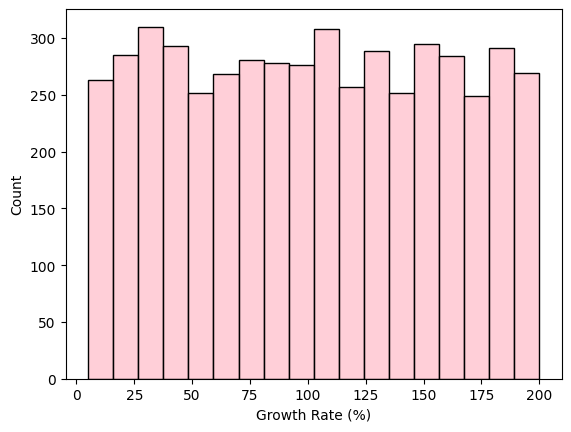

In [113]:
sns.histplot(df["Growth Rate (%)"],color="pink")

#### COUNTPLOT

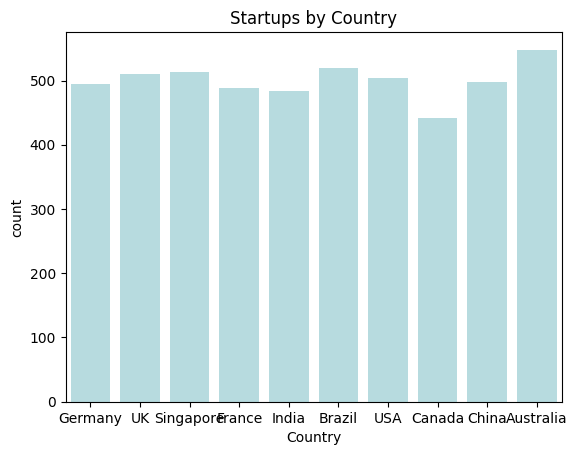

In [114]:
sns.countplot(data=df, x='Country', color="powderblue")
plt.title('Startups by Country')
plt.show()

#### SCATTERPLOT

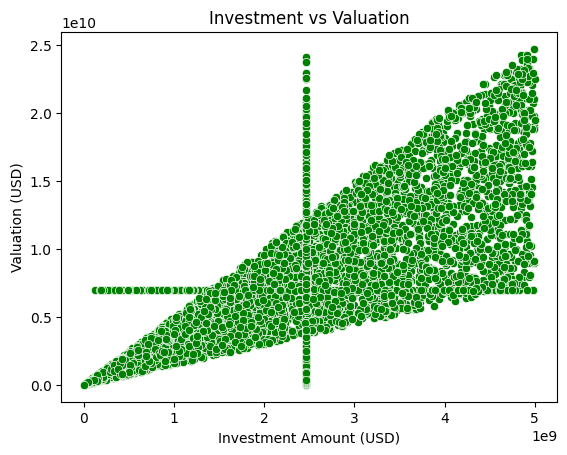

In [115]:
sns.scatterplot(data=df, x='Investment Amount (USD)', y='Valuation (USD)',color="green")
plt.title('Investment vs Valuation')
plt.xlabel('Investment Amount (USD)')
plt.ylabel('Valuation (USD)')
plt.show()

#### BARPLOT

C:\Users\Admin\AppData\Local\Temp\ipykernel_8520\3101783385.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Funding Rounds', y='Growth Rate (%)', palette='muted')


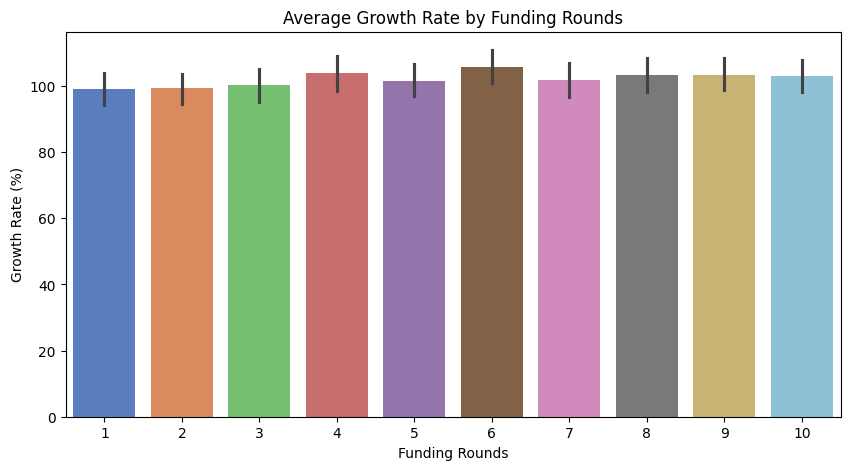

In [116]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Funding Rounds', y='Growth Rate (%)', palette='muted')
plt.title('Average Growth Rate by Funding Rounds')
plt.show()

In [117]:
numeric_df = df.select_dtypes(include='number')

#### HEATMAP

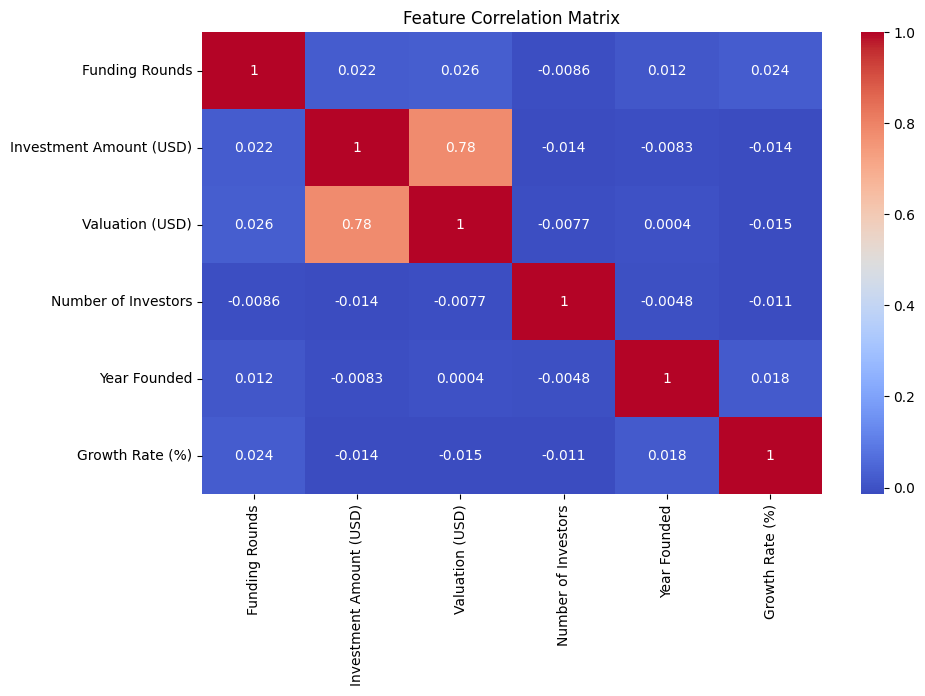

In [118]:
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(),annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

## CHECKING FOR OUTLIERS

#### BOXPLOT

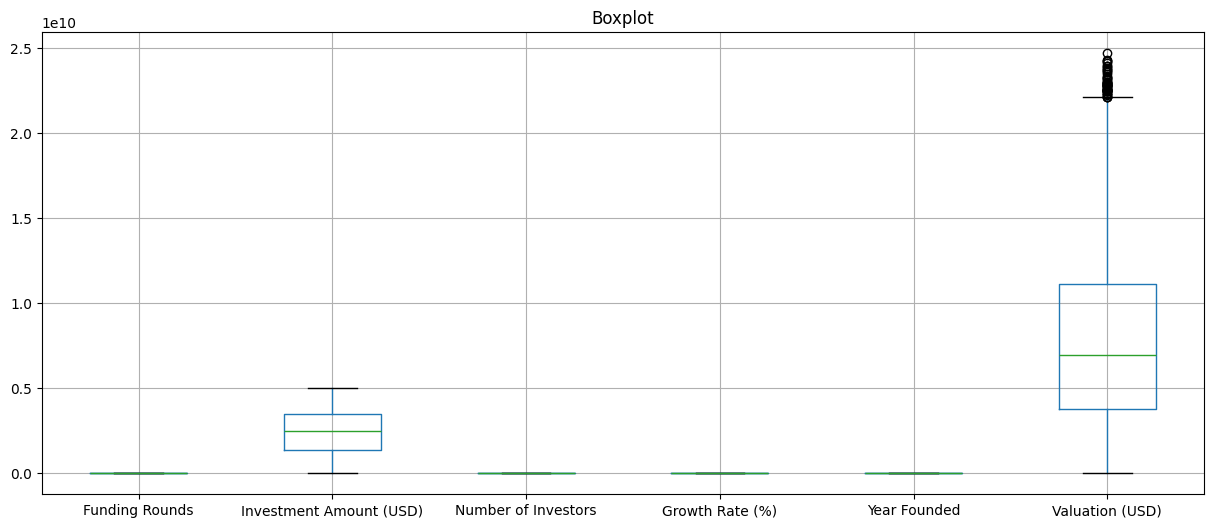

In [119]:
plt.figure(figsize=(15,6))
df.boxplot(column=['Funding Rounds', 'Investment Amount (USD)', 'Number of Investors', 'Growth Rate (%)', 'Year Founded','Valuation (USD)'])
plt.title("Boxplot")
plt.show()

In [120]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

df = remove_outliers(df, 'Valuation (USD)')


# MACHINE LEARNING MODELS

In [121]:
df['Success'] = df['Valuation (USD)'].apply(lambda x: 1 if x > 1_000_000_000 else 0)

C:\Users\Admin\AppData\Local\Temp\ipykernel_8520\1401556011.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Success'] = df['Valuation (USD)'].apply(lambda x: 1 if x > 1_000_000_000 else 0)


In [122]:
df

,Startup Name,Industry,Funding Rounds,Investment Amount (USD),Valuation (USD),Number of Investors,Country,Year Founded,Growth Rate (%),Success
0,Startup_1,Blockchain,8,1.335166e+09,6.621448e+09,50.000000,Germany,2012,77.10,1
1,Startup_2,SaaS,2,2.781498e+09,8.363214e+09,36.000000,UK,2006,105.52,1
2,Startup_3,EdTech,10,3.309032e+09,1.548270e+10,39.000000,Singapore,2016,190.47,1
3,Startup_4,Fintech,5,4.050196e+09,1.268253e+10,44.000000,France,2021,9.44,1
4,Startup_5,EdTech,9,1.645080e+09,6.887966e+09,48.000000,India,2011,192.00,1
...,...,...,...,...,...,...,...,...,...,...
4995,Startup_4996,EdTech,5,4.015771e+09,1.212346e+10,29.000000,Germany,2002,64.08,1
4996,Startup_4997,AI,2,3.619535e+09,1.107936e+10,14.000000,Brazil,2000,151.29,1
4997,Startup_4998,SaaS,10,4.257640e+08,8.277586e+08,29.000000,UK,2018,140.43,0
4998,Startup_4999,SaaS,4,4.220592e+08,1.895497e+09,6.000000,India,2017,122.93,1


In [123]:
x = df[['Funding Rounds', 'Investment Amount (USD)', 'Number of Investors']]
y = df['Success'] 

In [124]:
from sklearn.model_selection import train_test_split

In [125]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=30)

In [126]:
x_train

,Funding Rounds,Investment Amount (USD),Number of Investors
4620,8,9.536953e+08,46.000000
4084,9,2.379676e+08,5.000000
2616,6,1.216768e+09,33.000000
394,5,1.339003e+09,25.560217
4281,5,2.353845e+08,25.560217
...,...,...,...
4910,3,3.143771e+09,20.000000
928,5,4.556111e+09,42.000000
507,4,4.613500e+09,12.000000
3925,6,4.042674e+09,5.000000


In [127]:
x_test

,Funding Rounds,Investment Amount (USD),Number of Investors
1891,9,3.733267e+09,24.0
1286,5,4.569994e+09,49.0
2048,3,2.460634e+09,39.0
2998,7,4.133053e+09,2.0
1122,10,4.377954e+09,45.0
...,...,...,...
4800,7,4.203409e+09,20.0
91,7,1.868557e+09,48.0
1739,9,4.944073e+09,45.0
4588,3,2.613605e+09,32.0


In [128]:
y_train

4620    1
4084    0
2616    1
394     1
4281    0
       ..
4910    1
928     1
507     1
3925    1
4565    1
Name: Success, Length: 3959, dtype: int64

In [129]:
y_test

1891    1
1286    1
2048    1
2998    1
1122    1
       ..
4800    1
91      1
1739    1
4588    1
1463    1
Name: Success, Length: 990, dtype: int64

# 1. RANDOMFOREST CLASSIFIER

In [130]:
from sklearn.ensemble import RandomForestClassifier

In [131]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(x_train, y_train)


RandomForestClassifier(random_state=42)

In [132]:
y_pred = clf.predict(x_test)

In [133]:
len(y_pred)

990

In [134]:
clf.score(x_test,y_test)

0.9656565656565657

In [135]:
from sklearn.metrics import accuracy_score
acc1=accuracy_score(y_test,y_pred)
acc1

0.9656565656565657

## CLASSIFICATION REPORT

In [136]:
from sklearn.metrics import classification_report

In [137]:
cr=classification_report(y_test,y_pred,zero_division=0,output_dict=True)
cr

{'0': {'precision': 0.8148148148148148,
  'recall': 0.6470588235294118,
  'f1-score': 0.7213114754098361,
  'support': 68.0},
 '1': {'precision': 0.9743589743589743,
  'recall': 0.9891540130151844,
  'f1-score': 0.9817007534983854,
  'support': 922.0},
 'accuracy': 0.9656565656565657,
 'macro avg': {'precision': 0.8945868945868946,
  'recall': 0.8181064182722981,
  'f1-score': 0.8515061144541107,
  'support': 990.0},
 'weighted avg': {'precision': 0.9634003856226079,
  'recall': 0.9656565656565657,
  'f1-score': 0.9638154293468487,
  'support': 990.0}}

In [138]:
report=pd.DataFrame(cr)
report

,0,1,accuracy,macro avg,weighted avg
precision,0.814815,0.974359,0.965657,0.894587,0.963400
recall,0.647059,0.989154,0.965657,0.818106,0.965657
f1-score,0.721311,0.981701,0.965657,0.851506,0.963815
support,68.000000,922.000000,0.965657,990.000000,990.000000


In [139]:
report.transpose()

,precision,recall,f1-score,support
0,0.814815,0.647059,0.721311,68.000000
1,0.974359,0.989154,0.981701,922.000000
accuracy,0.965657,0.965657,0.965657,0.965657
macro avg,0.894587,0.818106,0.851506,990.000000
weighted avg,0.963400,0.965657,0.963815,990.000000


# 2. NAVIEBAYES CLASSIFICATION

## GAUSSIAN NB

In [140]:
from sklearn.naive_bayes import GaussianNB

In [141]:
classifier=GaussianNB()

In [142]:
classifier.fit(x_train,y_train)

GaussianNB()

In [143]:
y_pred=classifier.predict(x_test)

In [144]:
len(y_pred)

990

In [145]:
from sklearn.metrics import accuracy_score

In [146]:
acc2=accuracy_score(y_test,y_pred)
acc2

0.9313131313131313

## MULTINOMIAL NB

In [147]:
from sklearn.naive_bayes import MultinomialNB

In [148]:
cl=MultinomialNB()

In [149]:
cl.fit(x_train,y_train)

MultinomialNB()

In [150]:
y_pred=cl.predict(x_test)

In [151]:
from sklearn.metrics import accuracy_score
acc3=accuracy_score(y_test,y_pred)
acc3

0.8909090909090909

## BERNOULLI NB

In [152]:
from sklearn.naive_bayes import BernoulliNB

In [153]:
bn=BernoulliNB()

In [154]:
bn.fit(x_train,y_train)

BernoulliNB()

In [155]:
y_pred=bn.predict(x_test)

In [156]:
from sklearn.metrics import accuracy_score
acc4=accuracy_score(y_test,y_pred)
acc4

0.9313131313131313

# 3. SUPPORT VECTOR MACHINE MODEL

In [157]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

In [158]:
x = df[['Funding Rounds', 'Investment Amount (USD)', 'Number of Investors']]
y = df['Success'] 

In [159]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=30)

In [160]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [161]:
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [162]:
model=SVC(kernel='rbf')
model.fit(x_train,y_train)

SVC()

In [163]:
y_pred=model.predict(x_test)

In [164]:
print("CONFUSION_MATRIX \n \n ", confusion_matrix(y_test,y_pred))

CONFUSION_MATRIX 
 
  [[ 44  24]
 [ 10 912]]


In [165]:
from sklearn.metrics import classification_report
print("classification_report\n\n",classification_report(y_test,y_pred))

classification_report

               precision    recall  f1-score   support

           0       0.81      0.65      0.72        68
           1       0.97      0.99      0.98       922

    accuracy                           0.97       990
   macro avg       0.89      0.82      0.85       990
weighted avg       0.96      0.97      0.96       990



In [166]:
acc5=accuracy_score(y_test,y_pred)
acc5

0.9656565656565657

#### CONFUSION MATRIX

In [167]:
from sklearn.metrics import ConfusionMatrixDisplay

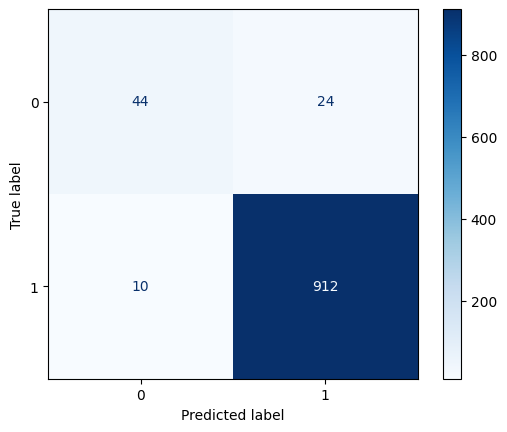

In [168]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,cmap='Blues')

# 4. KNN CLASSIFIER

In [169]:
from sklearn.neighbors import KNeighborsClassifier

In [170]:
x = df[['Funding Rounds', 'Investment Amount (USD)', 'Number of Investors']]
y = df['Success'] 

In [171]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=30)

In [172]:
knn=KNeighborsClassifier(n_neighbors=3)

In [173]:
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [174]:
y_pred=knn.predict(x_test)

In [175]:
acc6=accuracy_score(y_test,y_pred)
acc6

0.9696969696969697

# BEST MODEL SELECTION

In [176]:
final_accuracy= pd.DataFrame({
    "Model": ["Random Forest classifier","GaussianNB","MultinomialNB","BernouliNB","Support Vector Classifier","KNN Classifier"],
    "accuracy":[acc1,acc2,acc3,acc4,acc5,acc6]})

In [177]:
final_accuracy

,Model,accuracy
0,Random Forest classifier,0.965657
1,GaussianNB,0.931313
2,MultinomialNB,0.890909
3,BernouliNB,0.931313
4,Support Vector Classifier,0.965657
5,KNN Classifier,0.969697


C:\Users\Admin\AppData\Local\Temp\ipykernel_8520\4105236964.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="accuracy", y="Model", data=final_accuracy, palette="magma")


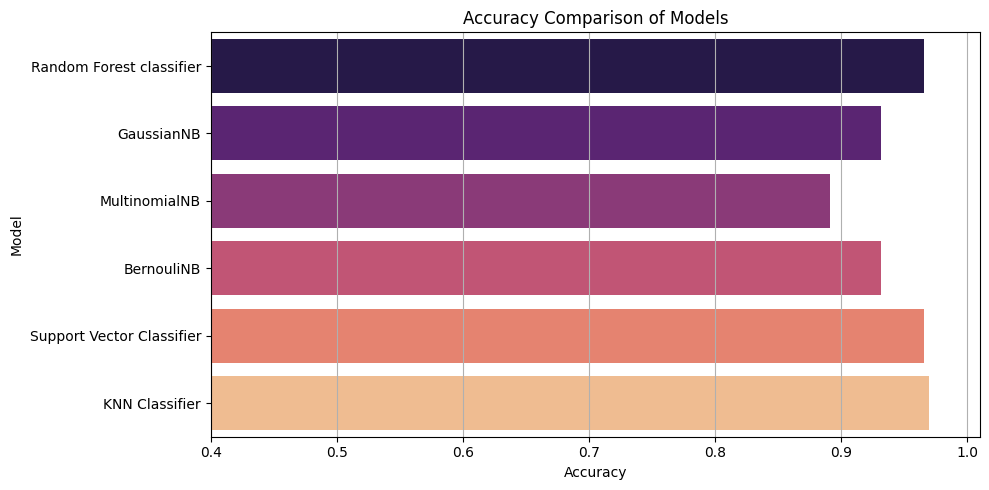

In [178]:
plt.figure(figsize=(10, 5))
sns.barplot(x="accuracy", y="Model", data=final_accuracy, palette="magma")
plt.title("Accuracy Comparison of Models")
plt.xlabel("Accuracy")
plt.xlim(0.40, 1.01)
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()